In [1]:
from datetime import datetime as dt
from typing import Tuple, Optional, Dict
from dfply import *
from sklearn.ensemble import RandomForestClassifier
from sklearn.mixture import BayesianGaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
from scipy.stats import norm
from scipy import stats
import scipy.stats as stats
import pandas as pd
import numpy as np
import math, os, uuid, sys, requests, re, time, statistics
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import seaborn as sns

Open Tables

In [2]:
file_name =  "DATA_RESPONSES.xlsx"
# Responses
RESPONSES = pd.read_excel(file_name, sheet_name = "RESPONSES")
RESPONSES = pd.DataFrame(RESPONSES)

#Concepts
CONCEPTS = pd.read_excel(file_name, sheet_name = "CONCEPTS")
CONCEPTS = pd.DataFrame(CONCEPTS)

#Questions
QUESTIONS = pd.read_excel(file_name, sheet_name = "QUESTIONS")
QUESTIONS = pd.DataFrame(QUESTIONS)

# Surveys
SURVEYS = pd.read_excel(file_name, sheet_name = "SURVEYS")
SURVEYS = pd.DataFrame(SURVEYS)


Create Data Model

In [3]:
QUESTIONS = QUESTIONS >> left_join(CONCEPTS, by='CONCEPT_KEY') 
QUESTIONS = QUESTIONS >> left_join(SURVEYS, by='SURVEY_KEY') 
RESPONSES = RESPONSES >> left_join(QUESTIONS, by='QUESTION_KEY') 

Create Variables

In [4]:
RESPONSES['TIMESTAMPS'] = pd.to_datetime(RESPONSES['TIMESTAMPS'], format = '%Y-%m-%d %H:%M:%S')
RESPONSES['YEAR'] = RESPONSES['TIMESTAMPS'].dt.strftime("%Y")
RESPONSES['MONTH'] = RESPONSES['TIMESTAMPS'].dt.strftime('%m')
RESPONSES['HOUR'] = RESPONSES['TIMESTAMPS'].dt.strftime("%H")
RESPONSES['YEAR_MONTH'] = RESPONSES['YEAR'].astype(str) + "-" + RESPONSES['MONTH'].astype(str)
RESPONSES['HOUR_RANGES'] = pd.cut(RESPONSES['TIMESTAMPS'].dt.hour,bins=[0, 12, 17, 24],labels=["(08 - 12]", "(12 - 17]", "(17 - 21]"],include_lowest=True)

Filter Conditions to Create Numeric Response

In [5]:
#Concept Key C1, C66, C67 (Open ended), C19, C50, C70, C78, C79 (Different scale Likert), and Eliminate manually the null values in the grouping C068-SESSION_RATING, C051-LIKELIHOOD_SUPPORT_SEEKING, C049LIKELIHOOD_COPING_STRATEGY_USE 
#Survey Type ACA, PER 
RESPONSES = RESPONSES >> mask(X.SURVEY_TYPE.isin(['ACA', 'MEN'])) >> mask(~(X.CONCEPT_KEY.isin(['C001', 'C019', 'C049', 'C050', 'C051','C066', 'C067', 'C068', 'C070', 'C078', 'C079', 'C080'])))

Mapping for Likert scale and numeric responses

In [6]:
# 1. Define your Switch cases in a dictionary
mapping = {"Strongly Disagree": 1, "Disagree": 2, "Neither Agree nor Disagree": 3, "Neither Agree or Disagree": 3, "Neutral": 3, "Agree": 4,  "Somewhat Agree": 4, "Strongly Agree": 5}
# 2. Apply it using .replace()
# We use errors='coerce' in to_numeric to handle the "BLANK()" part
RESPONSES['NUMERIC_RESPONSE'] = (RESPONSES['RESPONSE'].replace(mapping))
# 3. Convert to numbers and turn everything else into NaN (BLANK)
RESPONSES['NUMERIC_RESPONSE'] = pd.to_numeric(RESPONSES['NUMERIC_RESPONSE'], errors='coerce')
#Drop nan values in RESPONSE column
RESPONSES = RESPONSES >> mask(X.NUMERIC_RESPONSE.notnull())

In [7]:
T_DATA = (
    RESPONSES >> select(X.CONCEPT_NAME, X.SURVEY_PHASE, X.NUMERIC_RESPONSE) 
    >> group_by(X.CONCEPT_NAME, X.SURVEY_PHASE) 
    >> summarize(RESPONSE = mean(X.NUMERIC_RESPONSE))
    >> ungroup()
    >> arrange(X.SURVEY_PHASE, ascending=True))
T_DATA = T_DATA.pivot(index='CONCEPT_NAME', columns='SURVEY_PHASE', values='RESPONSE')
T_DATA.reset_index(inplace=True)

c:\Users\Diana\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\dfply\base.py:309: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dff = grouped.apply(self.function, *args, **kwargs)


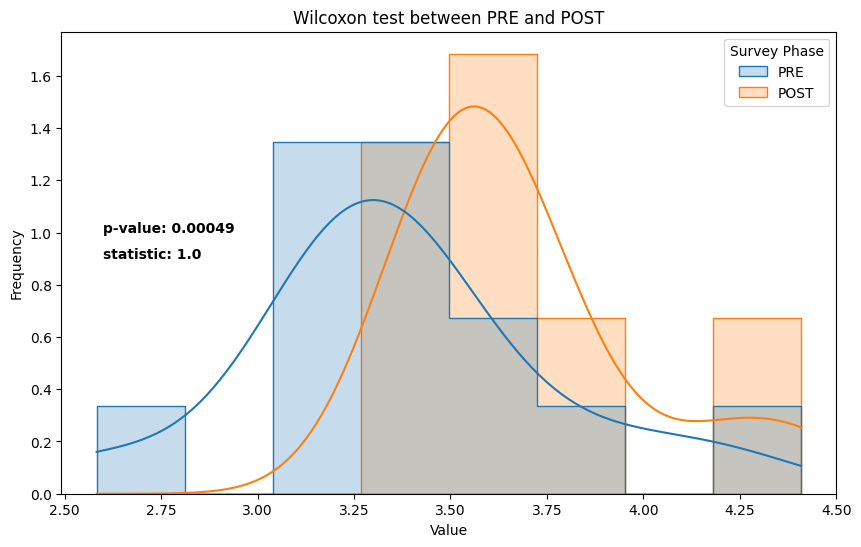

In [8]:
groupA = T_DATA['PRE']
groupB = T_DATA['POST']
statistic, p_value  = stats.wilcoxon(groupA, groupB, nan_policy='omit')
p_value = round(p_value,5) # more decimal since it's a lower value in general
statistic = round(statistic,5)
mean_groupA = groupA.mean()
mean_groupB = groupB.mean()
group_name = T_DATA.index.tolist()
# Get group names and define colors
# Init plots
df = pd.DataFrame({'PRE': groupA, 'POST': groupB})
# Melt the DataFrame to long format for Seaborn
df_long = df.melt(var_name='Survey Phase', value_name='Value')
# 2. Plot with KDE (Kernel Density Estimate)
plt.figure(figsize=(10, 6))
ax = sns.histplot(data=df_long, x='Value', hue='Survey Phase', element="step", kde=True, stat="density", common_norm=False)
plt.title("Overlapping Histograms with Density Curves")
# Add the p value and the t
p_value_text = f'p-value: {p_value}'
ax.text(2.6, 1, p_value_text, weight='bold')
value_text = f'statistic: {statistic}'
ax.text(2.6, 0.9, value_text, weight='bold')
# Add a title and axis label
ax.set_title('Wilcoxon test between PRE and POST')
ax.set_xlabel('Value')
ax.set_ylabel('Frequency')
# Show the plot
plt.show()

In [9]:
df_= RESPONSES >> select(X.CONCEPT_NAME, X.SURVEY_PHASE) >> transmute(CONCEPT = X.CONCEPT_NAME, PHASE = X.SURVEY_PHASE)
contingency_table = pd.crosstab(df_['CONCEPT'], df_['PHASE'])
chi2_statistic, p_value, degrees_of_freedom, expected_frequencies = chi2_contingency(contingency_table, correction=True)
p_value = round(p_value,3)
p_value_text = f'p-value: {p_value:.3f}'
chi2_text = f'chi2_statistic: {chi2_statistic:.3f}'

Clustered column chart from Concept ~ Phase using Numeric Response

c:\Users\Diana\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\dfply\base.py:309: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dff = grouped.apply(self.function, *args, **kwargs)
c:\Users\Diana\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\dfply\base.py:309: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dff = grouped.apply(self.function, *args, **kwargs)


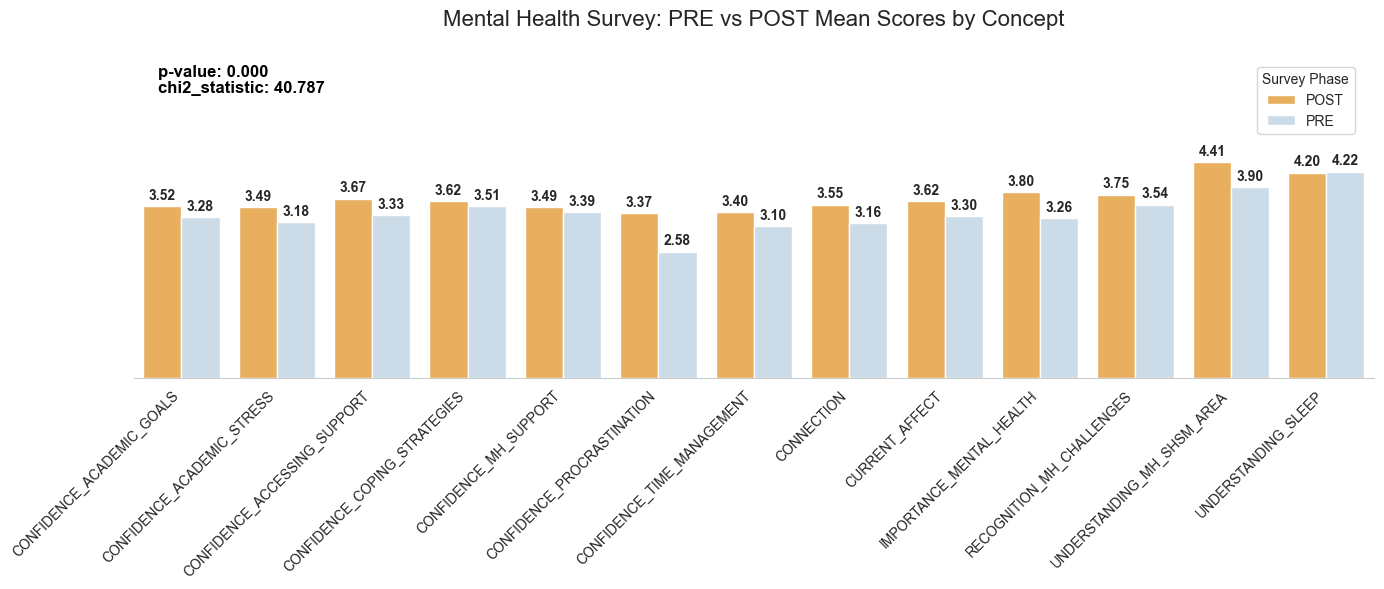

In [11]:
# Calculate the mean score per Concept and Phase
df = RESPONSES >> select(X.CONCEPT_NAME, X.SURVEY_PHASE, X.NUMERIC_RESPONSE) >> transmute(CONCEPT = X.CONCEPT_NAME, PHASE = X.SURVEY_PHASE, RESPONSE = X.NUMERIC_RESPONSE)
#df = df.dropna() >> mask(X.PHASE.isin(['PRE', 'POST']))
df = df >> group_by(X.CONCEPT, X.PHASE) >> summarize(RESPONSE = mean(X.RESPONSE)) >> arrange(X.PHASE, X.RESPONSE, ascending=True)
# Create the Clustered Column Chart
fig, ax = plt.subplots(figsize=(14, 6)) 
sns.set_style("whitegrid")
chart = sns.barplot(data=df,x='CONCEPT',y='RESPONSE',hue='PHASE',palette={'PRE': "#c6dcec", 'POST': '#ffb347'})
for container in chart.containers:
    chart.bar_label(container, fmt='%.2f', padding=3, fontsize=10, fontweight='bold')
plt.title('Mental Health Survey: PRE vs POST Mean Scores by Concept', fontsize=16, pad=25)
plt.xlabel('')
plt.ylabel('')
plt.yticks([]) # Keeps the Y-axis blank as requested
sns.despine(left=True)
ax.text(0.02, 0.95, p_value_text, transform=ax.transAxes, weight='bold', fontsize=12, color='black')
ax.text(0.02, 0.90, chi2_text, transform=ax.transAxes, weight='bold', fontsize=12, color='black')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 6.5) # Increased limit to ensure labels and stats text aren't cut off
plt.legend(title='Survey Phase', bbox_to_anchor=(0.9, 1), loc='upper left')
plt.tight_layout()
plt.show()

Clustered column chart from School Id ~ Phase using Numeric Response

c:\Users\Diana\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\dfply\base.py:309: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dff = grouped.apply(self.function, *args, **kwargs)


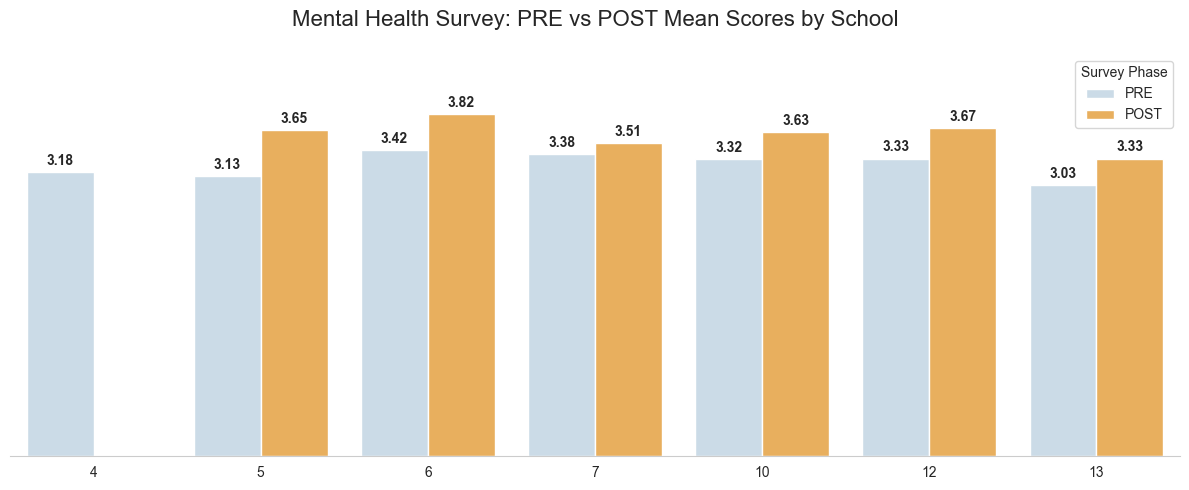

In [12]:
# Calculate the mean score per Concept and Phase
df = (RESPONSES >> select(X.SCHOOL_ID, X.SURVEY_PHASE, X.NUMERIC_RESPONSE) >> transmute(SCHOOL= X.SCHOOL_ID, PHASE = X.SURVEY_PHASE, RESPONSE = X.NUMERIC_RESPONSE)) 
df = df.dropna() >> mask(X.PHASE.isin(['PRE', 'POST']))
df = (df >> group_by(X.SCHOOL, X.PHASE) >> summarize(RESPONSE = mean(X.RESPONSE)) >> ungroup() >> arrange(X.PHASE, ascending=True))
# Create the Clustered Column Chart
plt.figure(figsize=(12, 5))
sns.set_style("whitegrid")
chart = sns.barplot(data=df,x='SCHOOL',y='RESPONSE',hue='PHASE',palette={'PRE': "#c6dcec", 'POST': '#ffb347'}) # Light Blue for PRE, Orange for POST
for container in chart.containers:
    chart.bar_label(container,fmt='%.2f',padding=3,fontsize=10,fontweight='bold'    )
# Styling and Labels
plt.title('Mental Health Survey: PRE vs POST Mean Scores by School', fontsize=16, pad=20)
plt.xlabel('')
plt.ylabel('')
plt.yticks([])  
sns.despine(left=True)
plt.ylim(0, 4.5) # Since the scale is 1-5
plt.legend(title='Survey Phase')
plt.tight_layout()

Line Chart using the Year and Month ~ Phase

c:\Users\Diana\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\dfply\base.py:309: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dff = grouped.apply(self.function, *args, **kwargs)


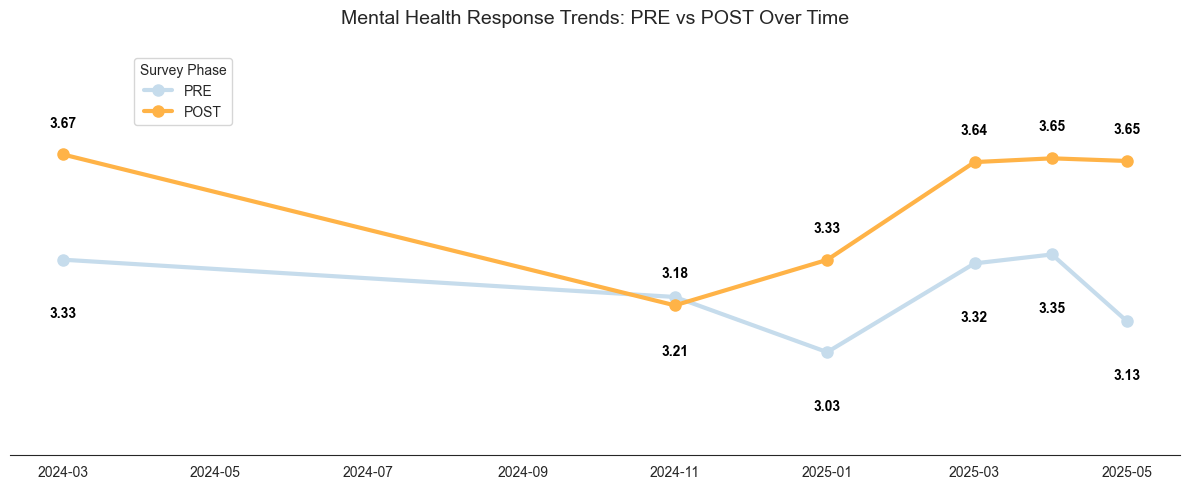

In [13]:
# Calculate the mean score per Concept and Phase
df = (RESPONSES >> select(X.YEAR_MONTH, X.SURVEY_PHASE, X.NUMERIC_RESPONSE) >> transmute(DATE= X.YEAR_MONTH, PHASE = X.SURVEY_PHASE, RESPONSE = X.NUMERIC_RESPONSE)) 
df = (df >> group_by(X.DATE, X.PHASE) >> summarize(RESPONSE = mean(X.RESPONSE)) >> ungroup() >> arrange(X.PHASE, ascending=True))
# Sort by Date
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values(by=['DATE', 'PHASE'])
palette = {'PRE': "#c6dcec", 'POST': '#ffb347'}
plt.figure(figsize=(12, 5))
sns.set_style("white") 
palette = {'PRE': "#c6dcec", 'POST': '#ffb347'}
for phase in ['PRE', 'POST']:
    subset = df[df['PHASE'] == phase]
    # Plot the line
    plt.plot(subset['DATE'],subset['RESPONSE'],marker='o',linestyle='-',linewidth=3,markersize=8,color=palette[phase],label=phase)
    # Add labels for EVERY point on BOTH lines
    for x, y in zip(subset['DATE'], subset['RESPONSE']):
        # Offset logic: POST labels go slightly above, PRE labels go slightly below
        offset = 0.08 if phase == 'POST' else -0.15
        plt.text(x, y + offset,f'{y:.2f}',ha='center',va='bottom' if phase == 'POST' else 'top',fontsize=10,fontweight='bold',color='black')
# --- BLANK Y-AXIS LOGIC ---
plt.title('Mental Health Response Trends: PRE vs POST Over Time', fontsize=14, pad=20)
plt.xlabel('')
plt.ylabel("")           
plt.yticks([])           
plt.xticks(rotation=0)
sns.despine(left=True, bottom=False) # Removes left Y-axis line
plt.grid(False)
plt.legend(title='Survey Phase', loc='upper left', bbox_to_anchor=(0.1, 1))
plt.ylim(2.7, 4) # Adjust based on your specific data range
plt.tight_layout()
plt.show()

Chi square test of independence between Concept and Survey Phase

In [14]:
df = (RESPONSES >> select(X.CONCEPT_NAME, X.SURVEY_PHASE, X.NUMERIC_RESPONSE) >> transmute(CONCEPT = X.CONCEPT_NAME, PHASE = X.SURVEY_PHASE)) 
df = df.dropna() >> mask(X.PHASE.isin(['PRE', 'POST']))
# Create the contingency table
contingency_table = pd.crosstab(df['CONCEPT'], df['PHASE'])
# Perform the test
chi2_statistic, p_value, degrees_of_freedom, expected_frequencies = chi2_contingency(contingency_table if 'contingency_table' in locals() else observed)
# Print the results
print("Contingency Table:")
print(contingency_table)
print(f"\nChi-square statistic: {chi2_statistic:.5f}")
print(f"P-value: {p_value:.5f}")
print(f"Degrees of freedom: {degrees_of_freedom}")
print("Expected frequencies:\n", expected_frequencies)
alpha = 0.05
if p_value < alpha:
    print(f"\nConclusion: Reject the null hypothesis. There is a significant association between the two variables (p < {alpha}).")
else:
    print(f"\nConclusion: Fail to reject the null hypothesis. There is no significant association between the two variables (p >= {alpha}).")

Contingency Table:
PHASE                         POST  PRE
CONCEPT                                
CONFIDENCE_ACADEMIC_GOALS      151  235
CONFIDENCE_ACADEMIC_STRESS     150  235
CONFIDENCE_ACCESSING_SUPPORT    24   87
CONFIDENCE_COPING_STRATEGIES    29   87
CONFIDENCE_MH_SUPPORT           37  102
CONFIDENCE_PROCRASTINATION     151  235
CONFIDENCE_TIME_MANAGEMENT     151  235
CONNECTION                     187  334
CURRENT_AFFECT                 188  337
IMPORTANCE_MENTAL_HEALTH       151  234
RECOGNITION_MH_CHALLENGES       36  101
UNDERSTANDING_MH_SHSM_AREA      22   20
UNDERSTANDING_SLEEP            148  230

Chi-square statistic: 40.78668
P-value: 0.00005
Degrees of freedom: 12
Expected frequencies:
 [[141.14703618 244.85296382]
 [140.78137028 244.21862972]
 [ 40.58891455  70.41108545]
 [ 42.41724403  73.58275597]
 [ 50.82755966  88.17244034]
 [141.14703618 244.85296382]
 [141.14703618 244.85296382]
 [190.51193226 330.48806774]
 [191.97459584 333.02540416]
 [140.78137028 244.218629

Radar Plot for Academic Achievement

c:\Users\Diana\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\dfply\base.py:309: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dff = grouped.apply(self.function, *args, **kwargs)
c:\Users\Diana\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\dfply\base.py:309: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dff = grouped.apply(self.function, *args, **kwargs)


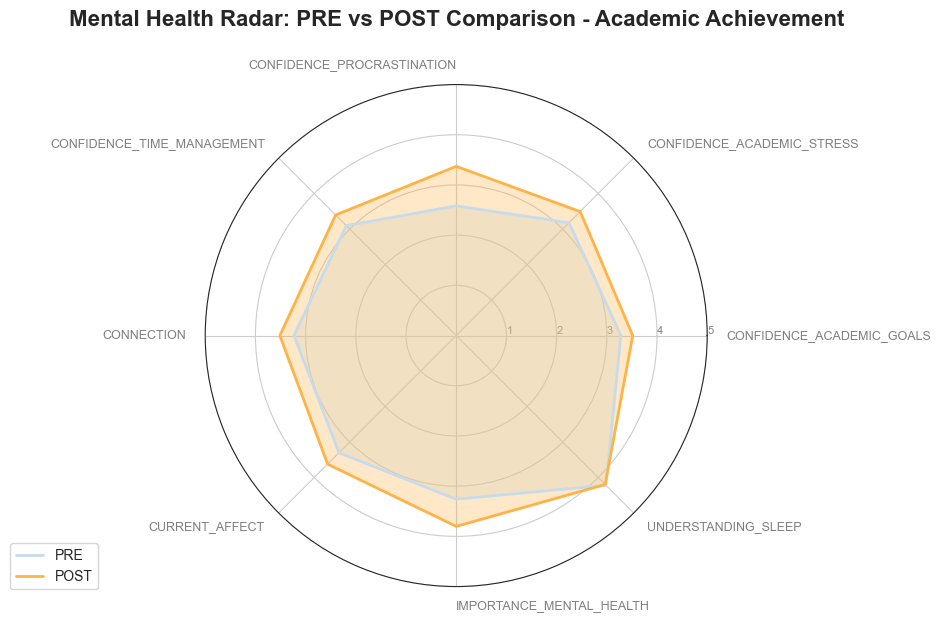

In [15]:
# Prepare the data (Pivot so Phases are columns and Concepts are rows)
df = RESPONSES >> mask(X.SURVEY_TYPE.isin(['ACA'])) >> select(X.CONCEPT_NAME, X.SURVEY_PHASE, X.NUMERIC_RESPONSE) >> transmute(CONCEPT = X.CONCEPT_NAME, PHASE = X.SURVEY_PHASE, RESPONSE = X.NUMERIC_RESPONSE) 
df = df >> group_by(X.CONCEPT, X.PHASE) >> summarize(RESPONSE = mean(X.RESPONSE)) >> arrange(X.PHASE, X.RESPONSE, ascending=True)
radar_df = df.pivot(index='CONCEPT', columns='PHASE', values='RESPONSE').dropna()
# Basic Setup
categories = radar_df.index.tolist()
N = len(categories)
# Angles for each axis (divide the circle into N parts)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1] # Close the circle
plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)
# Plotting PRE Phase
values_pre = radar_df['PRE'].tolist()
values_pre += values_pre[:1] # Close the shape
ax.plot(angles, values_pre, linewidth=2, linestyle='solid', label='PRE', color="#c6dcec")
ax.fill(angles, values_pre, color="#c6dcec", alpha=0.3)
# Plotting POST Phase
values_post = radar_df['POST'].tolist()
values_post += values_post[:1] # Close the shape
ax.plot(angles, values_post, linewidth=2, linestyle='solid', label='POST', color="#ffb347")
ax.fill(angles, values_post, color="#ffb347", alpha=0.3)
# Styling the Chart
plt.xticks(angles[:-1], categories, color='grey', size=9)
ax.set_rlabel_position(0)
plt.yticks([1, 2, 3, 4, 5], ["1", "2", "3", "4", "5"], color="grey", size=8)
plt.ylim(0, 5)
plt.title('Mental Health Radar: PRE vs POST Comparison - Academic Achievement', size=16, y=1.1, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(-0.2, 0.1))
# Adjust label alignment to prevent overlap
for label, angle in zip(ax.get_xticklabels(), angles):
    if 0 <= angle < np.pi/2 or 3*np.pi/2 <= angle < 2*np.pi:
        label.set_horizontalalignment('left')
    else:
        label.set_horizontalalignment('right')
plt.tight_layout()
plt.show()

Radar Plot for Student Mental Health

c:\Users\Diana\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\dfply\base.py:309: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dff = grouped.apply(self.function, *args, **kwargs)
c:\Users\Diana\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\dfply\base.py:309: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dff = grouped.apply(self.function, *args, **kwargs)


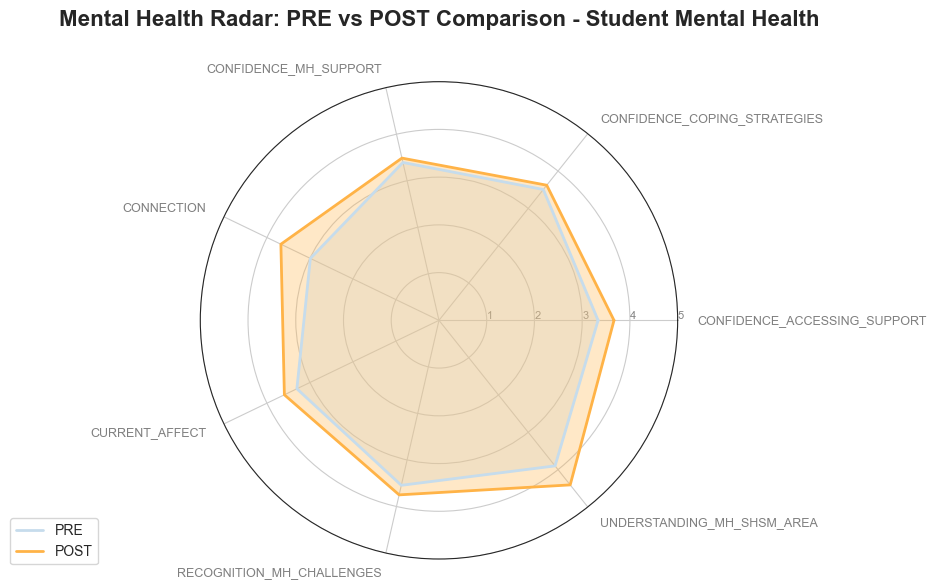

In [16]:
# Prepare the data (Pivot so Phases are columns and Concepts are rows)
df = RESPONSES >> mask(X.SURVEY_TYPE.isin(['MEN'])) >> select(X.CONCEPT_NAME, X.SURVEY_PHASE, X.NUMERIC_RESPONSE) >> transmute(CONCEPT = X.CONCEPT_NAME, PHASE = X.SURVEY_PHASE, RESPONSE = X.NUMERIC_RESPONSE) 
df = df >> group_by(X.CONCEPT, X.PHASE) >> summarize(RESPONSE = mean(X.RESPONSE)) >> arrange(X.PHASE, X.RESPONSE, ascending=True)
radar_df = df.pivot(index='CONCEPT', columns='PHASE', values='RESPONSE').dropna()
# Basic Setup
categories = radar_df.index.tolist()
N = len(categories)
# Angles for each axis (divide the circle into N parts)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1] # Close the circle
plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)
# Plotting PRE Phase
values_pre = radar_df['PRE'].tolist()
values_pre += values_pre[:1] # Close the shape
ax.plot(angles, values_pre, linewidth=2, linestyle='solid', label='PRE', color="#c6dcec")
ax.fill(angles, values_pre, color="#c6dcec", alpha=0.3)
# Plotting POST Phase
values_post = radar_df['POST'].tolist()
values_post += values_post[:1] # Close the shape
ax.plot(angles, values_post, linewidth=2, linestyle='solid', label='POST', color="#ffb347")
ax.fill(angles, values_post, color="#ffb347", alpha=0.3)
# Styling the Chart
plt.xticks(angles[:-1], categories, color='grey', size=9)
ax.set_rlabel_position(0)
plt.yticks([1, 2, 3, 4, 5], ["1", "2", "3", "4", "5"], color="grey", size=8)
plt.ylim(0, 5)
plt.title('Mental Health Radar: PRE vs POST Comparison - Student Mental Health', size=16, y=1.1, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(-0.2, 0.1))
# Adjust label alignment to prevent overlap
for label, angle in zip(ax.get_xticklabels(), angles):
    if 0 <= angle < np.pi/2 or 3*np.pi/2 <= angle < 2*np.pi:
        label.set_horizontalalignment('left')
    else:
        label.set_horizontalalignment('right')
plt.tight_layout()
plt.show()

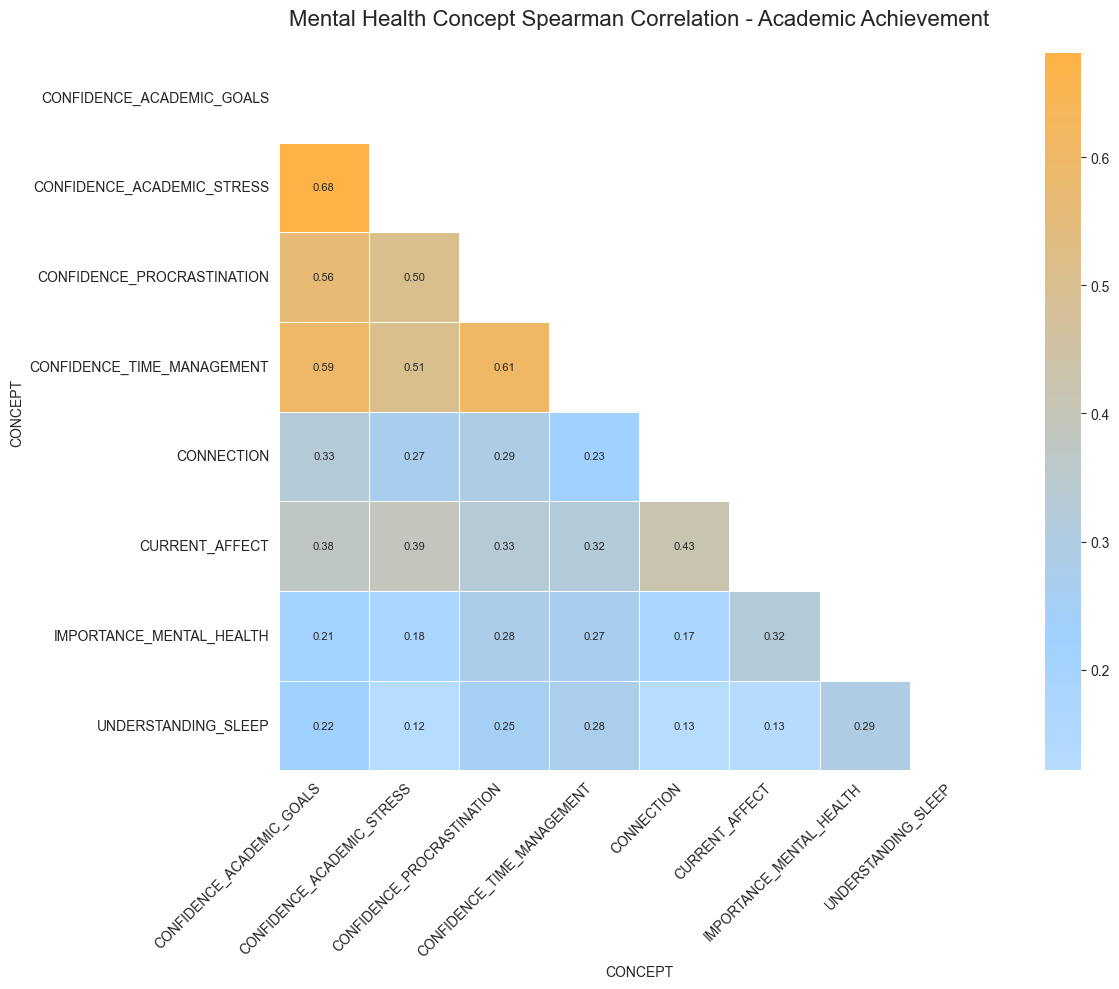

In [17]:
custom_cmap = mcolors.LinearSegmentedColormap.from_list('my_custom_cmap', ['#FFFFFF','#FFFFFF', '#A0D1FF','#ffb347'], N=250)
# Pivot the data (ID as rows, Concepts as columns)
# This represents each student's "profile" across all concepts
df_ACA = RESPONSES[RESPONSES.SURVEY_TYPE.isin(['ACA'])] >> transmute(ID = X.RESPONSE_ID, CONCEPT = X.CONCEPT_NAME, PHASE = X.SURVEY_PHASE, SURVEY_NAME = X.SURVEY_NAME, RESPONSE = X.NUMERIC_RESPONSE) >> arrange(X.RESPONSE, X.PHASE, ascending=False)
pivot = df_ACA.pivot_table(index='ID', columns='CONCEPT', values='RESPONSE', aggfunc='mean')
# Filter for stability (min_n ensures we only correlate concepts with enough data)
min_n = 50 
pivot = pivot.loc[:, pivot.notna().sum() >= min_n]
# Calculate Spearman Correlation
corr = pivot.corr(method='spearman')
# Create the Heatmap
plt.figure(figsize=(12, 10))
sns.set_style("white")
# Mask the upper triangle (it's a mirror of the lower half)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr,mask=mask,cmap=custom_cmap,center=0,annot=True,fmt='.2f',linewidths=.5,annot_kws={"size": 8})
plt.title('Mental Health Concept Spearman Correlation - Academic Achievement', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

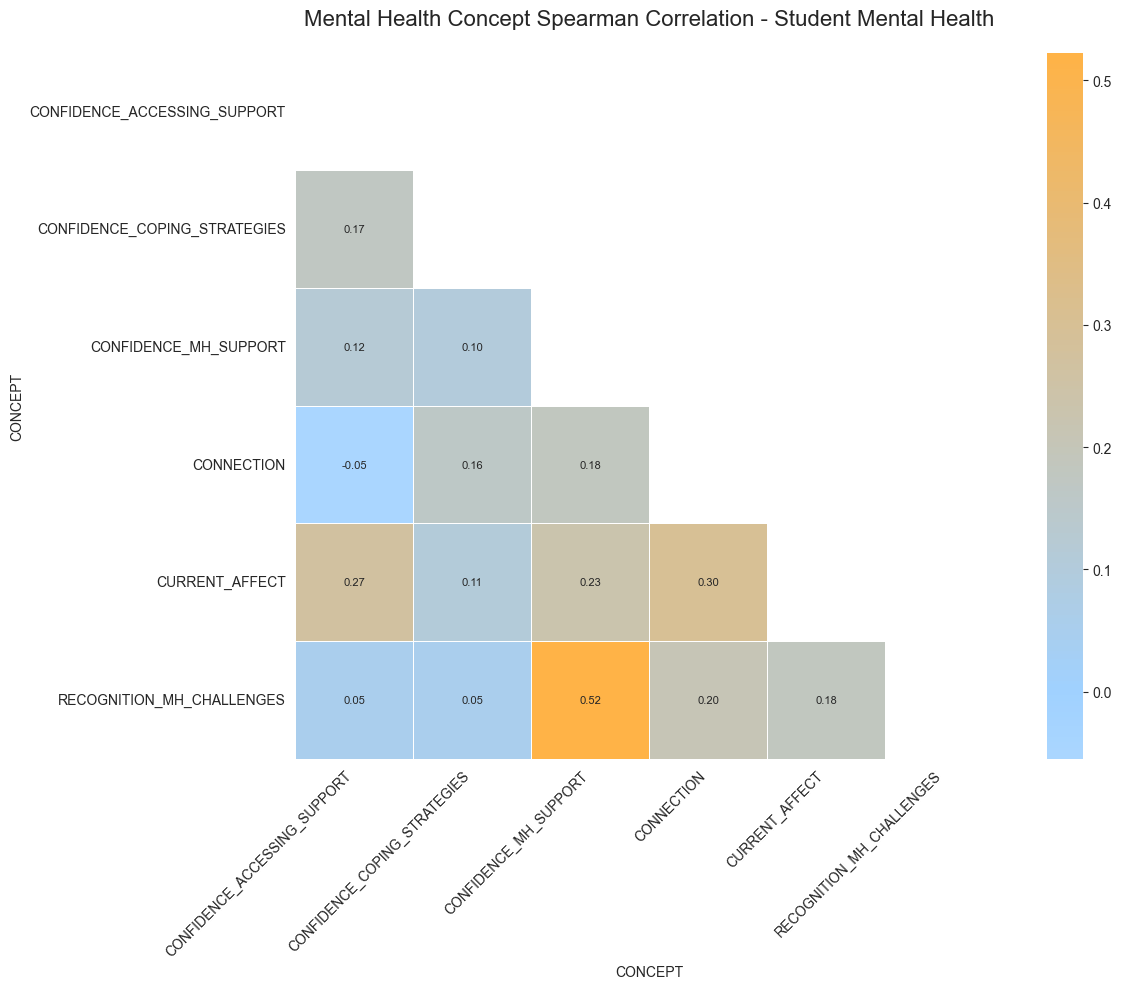

In [18]:
custom_cmap = mcolors.LinearSegmentedColormap.from_list('my_custom_cmap', ['#FFFFFF', '#A0D1FF','#ffb347'], N=250)
df_MEN = RESPONSES[RESPONSES.SURVEY_TYPE.isin(['MEN'])] >> transmute(ID = X.RESPONSE_ID, CONCEPT = X.CONCEPT_NAME, PHASE = X.SURVEY_PHASE, SURVEY_NAME = X.SURVEY_NAME, RESPONSE = X.NUMERIC_RESPONSE) >> arrange(X.RESPONSE, X.PHASE, ascending=False)
pivot = df_MEN.pivot_table(index='ID', columns='CONCEPT', values='RESPONSE', aggfunc='mean')
# Filter for stability (min_n ensures we only correlate concepts with enough data)
min_n = 50 
pivot = pivot.loc[:, pivot.notna().sum() >= min_n]
# Calculate Spearman Correlation
corr = pivot.corr(method='spearman')
# Create the Heatmap
plt.figure(figsize=(12, 10))
sns.set_style("white")
# Mask the upper triangle (it's a mirror of the lower half)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr,mask=mask,cmap=custom_cmap,center=0,annot=True,fmt='.2f',linewidths=.5,annot_kws={"size": 8})
plt.title('Mental Health Concept Spearman Correlation - Student Mental Health', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Feature Importances via Random Forest

C:\Users\Diana\AppData\Local\Temp\ipykernel_37788\494864652.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')


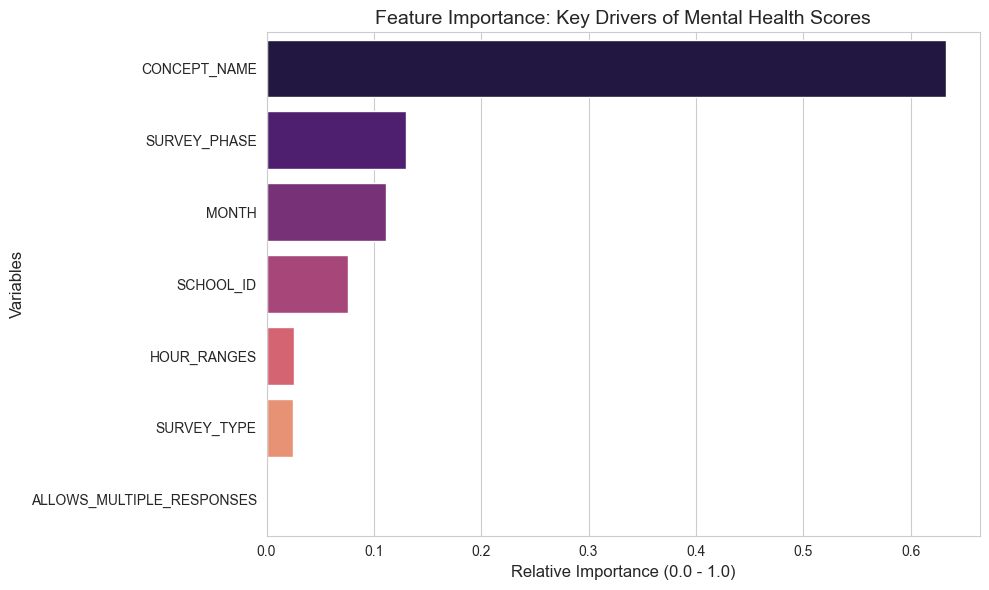

                     Feature  Importance
1               CONCEPT_NAME    0.633009
0               SURVEY_PHASE    0.129994
2                      MONTH    0.110886
4                  SCHOOL_ID    0.075943
5                HOUR_RANGES    0.025403
3                SURVEY_TYPE    0.024765
6  ALLOWS_MULTIPLE_RESPONSES    0.000000


In [19]:
df = RESPONSES >> select(X.NUMERIC_RESPONSE, X.SURVEY_PHASE, X.CONCEPT_NAME, X.MONTH, X.SURVEY_TYPE, X.SCHOOL_ID, X.HOUR_RANGES, X.ALLOWS_MULTIPLE_RESPONSES) 
df = df.dropna()
target = 'NUMERIC_RESPONSE'
features = ['SURVEY_PHASE','CONCEPT_NAME','MONTH','SURVEY_TYPE','SCHOOL_ID','HOUR_RANGES','ALLOWS_MULTIPLE_RESPONSES']
# Data Cleaning
# Convert the target to numeric (handles cases where it might be text)
df[target] = pd.to_numeric(df[target], errors='coerce')
# Keep only the rows where we have all features and a valid target
model_df = df[features + [target]].dropna().copy()
# 4. Encoding Categorical Variables
# Machine Learning models need numbers, so we convert text to 'labels'
le = LabelEncoder()
categorical_cols = ['SURVEY_PHASE', 'CONCEPT_NAME', 'SURVEY_TYPE','SCHOOL_ID', 'HOUR_RANGES', 'ALLOWS_MULTIPLE_RESPONSES']
for col in categorical_cols:
    model_df[col] = le.fit_transform(model_df[col].astype(str))
# Train the Random Forest Model
X = model_df[features]
y = model_df[target]
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)
# Extract and Visualize Importance
importance_df = pd.DataFrame({'Feature': features,'Importance': model.feature_importances_}).sort_values(by='Importance', ascending=False)
# Plotting
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')
plt.title('Feature Importance: Key Drivers of Mental Health Scores', fontsize=14)
plt.xlabel('Relative Importance (0.0 - 1.0)', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.tight_layout()
plt.show()
# Print the table for your reference
print(importance_df)

To explain the methodology of Feature Importance via Random Forest, we focus on how the model identifies the "drivers" of your mental health data. The process begins by building hundreds of Decision Trees. Each tree attempts to predict the NUMERIC_RESPONSE by splitting the data into groups based on your variables (e.g., "Is the Phase POST?" or "Is the Concept Sleep?"). The methodology measures Gini Impurity or Variance Reduction: if a variable like CONCEPT_NAME consistently creates the most accurate, distinct groups of scores, it earns a higher importance weight. Because this happens across an entire "forest" of trees, the final results are averaged and normalized to total 100%. This allows you to quantify exactly how much influence the curriculum has versus external factors like the school or the month. It captures complex, non-linear interactions that simple correlations often miss.

Random Forest Regressor Model

In [20]:
# Prepare Features
model_df = df[['CONCEPT_NAME','SURVEY_PHASE', 'MONTH','SCHOOL_ID','NUMERIC_RESPONSE']].dropna()
# Encode Categories to Numbers
le = LabelEncoder()
model_df['CONCEPT_ENC'] = le.fit_transform(model_df['CONCEPT_NAME'])
model_df['PHASE_ENC'] = le.fit_transform(model_df['SURVEY_PHASE'])
# Train the Model
X = model_df[['CONCEPT_ENC', 'PHASE_ENC', 'MONTH','SCHOOL_ID']]
y = model_df['NUMERIC_RESPONSE']
model = RandomForestRegressor(n_estimators=100)
model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [21]:
# Calculate Model Accuracy Metrics
# We use the data the model was trained on (X, y) to see how well it fits
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
# Print the Executive Summary
print("--- Model Performance Summary ---")
print(f"R-Squared (Accuracy): {r2:.2f}")
print(f"Mean Absolute Error: {mae:.2f} points")
print("-" * 33)

--- Model Performance Summary ---
R-Squared (Accuracy): 0.16
Mean Absolute Error: 0.78 points
---------------------------------


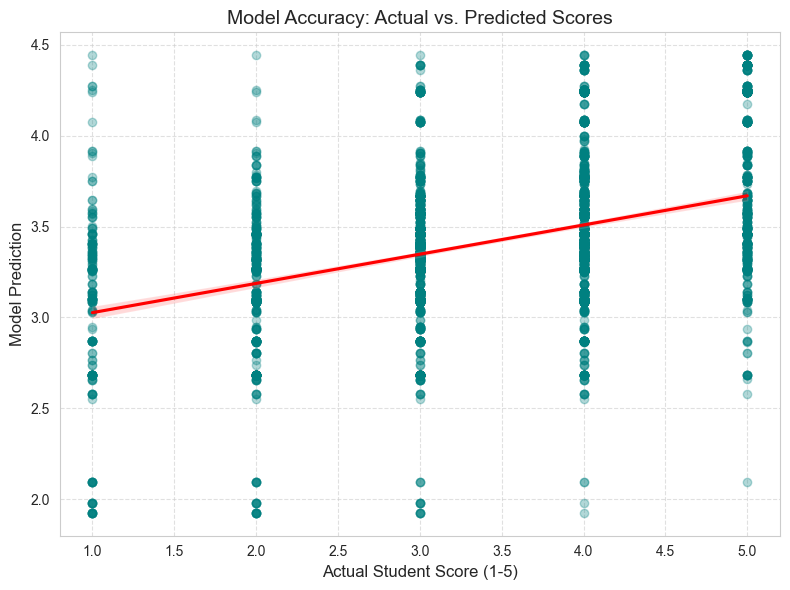

In [22]:
plt.figure(figsize=(8, 6))
# We add a little 'jitter' so the points don't all stack on top of each other
sns.regplot(x=y, y=y_pred, scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red'})
plt.title('Model Accuracy: Actual vs. Predicted Scores', fontsize=14)
plt.xlabel('Actual Student Score (1-5)', fontsize=12)
plt.ylabel('Model Prediction', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()